In [210]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# Importing Libraries


In [211]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [212]:
df_train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

# EDA

In [213]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [214]:
df_train.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
36,37,1,3,"Mamee, Mr. Hanna",male,NaN,0,0,2677,7.2292,NaN,C
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.5500,C22 C26,S
727,728,1,3,"Mannion, Miss. Margareth",female,NaN,0,0,36866,7.7375,NaN,Q
163,164,0,3,"Calic, Mr. Jovo",male,17.0,0,0,315093,8.6625,NaN,S
478,479,0,3,"Karlsson, Mr. Nils August",male,22.0,0,0,350060,7.5208,NaN,S


In [215]:
df_train['Sex'].unique()

array(['male', 'female'], dtype=object)

In [216]:
df_train.shape

(891, 12)

In [217]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [218]:
men = df_train.loc[df_train.Sex == 'male']["Survived"]
rate_men = (sum(men)/len(men)) * 100

print("Percent of men who survived:", rate_men)

Percent of men who survived: 18.890814558058924


In [219]:
female = df_train.loc[df_train.Sex == 'female']["Survived"]
rate_female = (sum(female)/len(female)) * 100

print("Percentage of female who survived:", rate_female)

Percentage of female who survived: 74.20382165605095


## Data Visualization 

<function matplotlib.pyplot.show(close=None, block=None)>

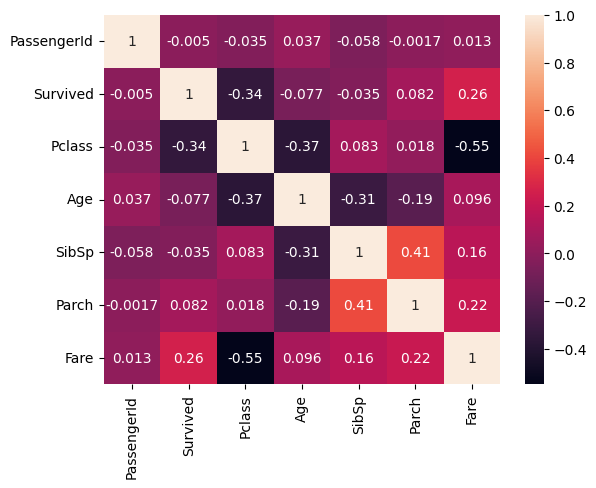

In [220]:
corr_matrix = df_train.corr(numeric_only=True)
corr_matrix   #It shows the correlation in the table view
sns.heatmap(corr_matrix, annot =True)   #We plot the Heatmap
plt.show

#### Heatmap gives a clear visualation that the highest correlation with groups [Survived - Fare,  SibSp - Parch,  Parch - Fare] 

Text(0, 0.5, 'Count')

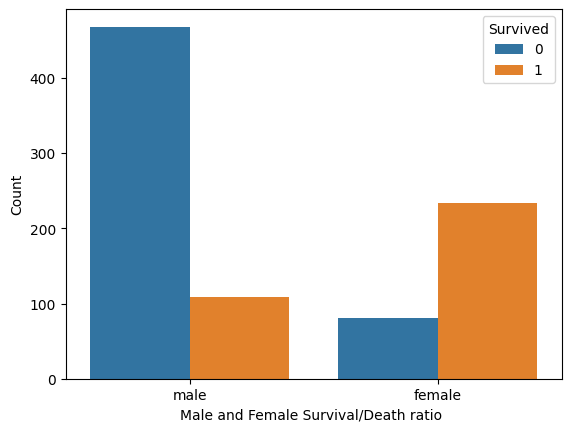

In [221]:
sns.countplot(x = 'Sex', hue = 'Survived', data = df_train)
plt.xlabel("Male and Female Survival/Death ratio ")
plt.ylabel("Count")

Text(0.5, 1.0, 'Survive in Passenger Class')

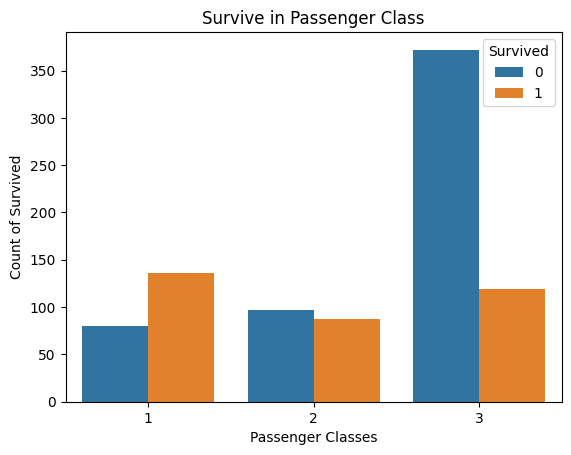

In [222]:
sns.countplot(x = 'Pclass', hue = 'Survived' , data = df_train)
plt.xlabel('Passenger Classes')
plt.ylabel('Count of Survived')
plt.title('Survive in Passenger Class')

<Axes: xlabel='Embarked', ylabel='count'>

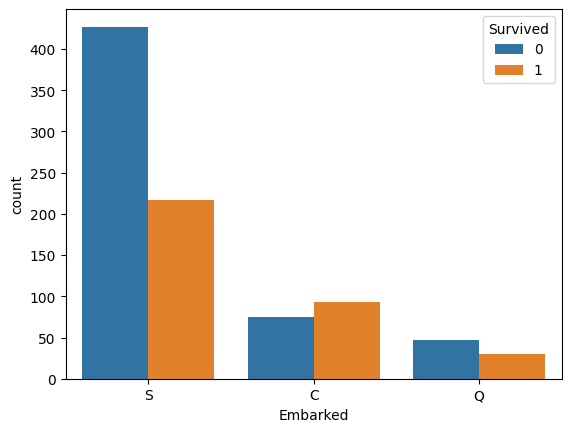

In [223]:
sns.countplot(x= 'Embarked', hue = 'Survived', data = df_train)


In [224]:
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1

<Axes: xlabel='FamilySize', ylabel='Survived'>

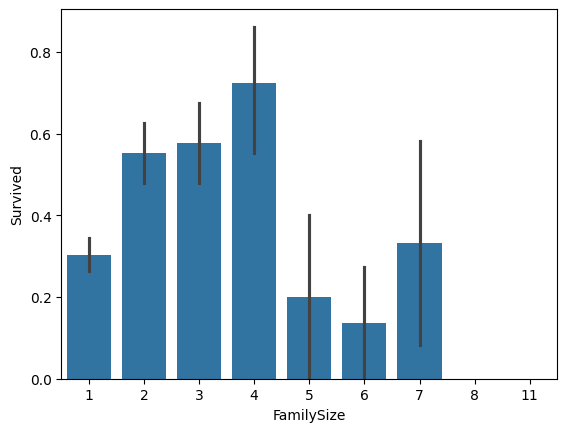

In [225]:
sns.barplot(x='FamilySize', y='Survived', data=df_train)

# Preprocessing

In [226]:
df_train.drop(['Cabin','Name','Ticket'], axis=1, inplace=True )
df_train.dropna(subset=['Embarked'],inplace=True )


In [227]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    object 
 4   Age          712 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Fare         889 non-null    float64
 8   Embarked     889 non-null    object 
 9   FamilySize   889 non-null    int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 76.4+ KB


In [228]:
df_train['Age'].fillna(df_train['Age'].mean(),inplace=True)


In [229]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    object 
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Fare         889 non-null    float64
 8   Embarked     889 non-null    object 
 9   FamilySize   889 non-null    int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 76.4+ KB


In [230]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()

In [231]:
df_train['Sex']=label.fit_transform(df_train['Sex'])
df_train['Embarked']=label.fit_transform(df_train['Embarked'])


In [232]:
df_train=df_train.astype(int)

In [233]:
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,1,0,3,1,22,1,0,7,2,2
1,2,1,1,0,38,1,0,71,0,2
2,3,1,3,0,26,0,0,7,2,1
3,4,1,1,0,35,1,0,53,2,2
4,5,0,3,1,35,0,0,8,2,1


In [234]:
x=df_train.drop(['Survived'],axis=1)
y=df_train['Survived']

# Train Test Split

In [235]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Model Building

# Model - 1

In [236]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

## Prediction

In [237]:
y_pred=model.predict(X_test)

## Accuracy

In [238]:
accuracy_score(y_test,y_pred)

0.7921348314606742

## Confusion Matrix

In [239]:
confusion_matrix(y_test,y_pred)

array([[90, 19],
       [18, 51]])

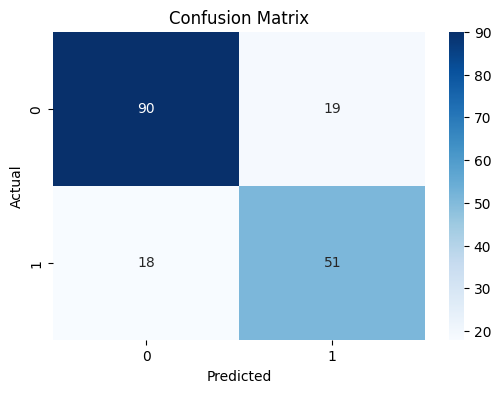

In [240]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model - 2

In [241]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

## Prediction

In [242]:
y_pred = xgb_model.predict(X_test)

## Accuracy

In [243]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.8202247191011236


## Confusion Matrix

In [244]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[94 15]
 [17 52]]


## Classification Report

In [245]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.86      0.85       109
           1       0.78      0.75      0.76        69

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178



In [246]:
accuracy_score(y_test,y_pred)

0.8202247191011236

# Model 3

In [247]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Model
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 271, number of negative: 440
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000962 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 392
[LightGBM] [Info] Number of data points in the train set: 711, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381153 -> initscore=-0.484656
[LightGBM] [Info] Start training from score -0.484656
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(learning_rate=0.05, max_depth=4, n_estimators=300,
               random_state=42)

In [248]:
print('Error')

Error


## Prediction


In [249]:
y_pred = lgbm_model.predict(X_test)

## Accuracy

In [250]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.797752808988764


# Confusion Matrix

In [251]:
cm = confusion_matrix(y_test, y_pred)

# Classification Report

In [252]:

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.84      0.84       109
           1       0.75      0.72      0.74        69

    accuracy                           0.80       178
   macro avg       0.79      0.78      0.79       178
weighted avg       0.80      0.80      0.80       178



In [253]:
accuracy_score(y_test,y_pred)

0.797752808988764

## SAVE PASSENGER ID

In [254]:
submission_ids = df_test['PassengerId']

## FEATURE ENGINEERING TEST DATA


In [255]:
df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1

## DROP COLUMNS TEST DATA


In [256]:
df_test.drop(['Cabin','Name','Ticket'], axis=1, inplace=True)


# Encode categorical columns

In [257]:

from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

df_test['Sex'] = label.fit_transform(df_test['Sex'])
df_test['Embarked'] = label.fit_transform(df_test['Embarked'])

# Fill missing values

In [258]:

df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())
df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].median())

# Match training feature order

In [259]:

df_test = df_test[['PassengerId','Pclass','Sex','Age',
                   'SibSp','Parch','Fare','Embarked','FamilySize']]

# Predict


In [260]:
test_predictions = xgb_model.predict(df_test)

# Submission.csv 

In [261]:
submission = pd.DataFrame({
    'PassengerId': submission_ids,
    'Survived': test_predictions.astype(int)
})

submission.to_csv('submission.csv', index=False)

print("submission.csv created successfully!")
submission.head()

submission.csv created successfully!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


# The Accuracy of this model is 75.358%